In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# 1. Load dan bersihkan data
file_path = "Rata-rata Pengeluaran Perkapita Seminggu  Menurut Kelompok Makanan Minuman Jadi di Jawa Timur, 2024.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

In [3]:
df.head()

,Kabupaten/Kota,Roti tawar,"Roti manis, roti lainnya","Kue kering, biskuit, semprong","Kue basah (kue lapis, bika ambon, lemper, dsb)","Makanan gorengan (tahu, tempe, bakwan, pisang)",Makanan gorengan,Bubur kacang hijau,"Gado-gado, ketoprak, pecel",Nasi campur/rames,...,"Siomay, batagor",Makanan jadi lainnya,Air kemasan,Air kemasan galon,"Air teh kemasan, minuman bersoda/mengandung CO2","Sari buah kemasan, minuman kesehatan, minuman berenergi","Minuman jadi (kopi, kopi susu, teh, susu coklat, dsb)",Es krim,Es lainnya,Minuman keras
0,Pacitan,81,1596,974,1933,2443,181,415,779,8286,...,910,426,431,405,180,259,7190,571,461,-
1,Ponorogo,212,1196,1026,2042,2714,191,436,2035,3724,...,652,1462,231,1453,281,222,4363,758,1418,-
2,Trenggalek,72,824,820,1583,1446,105,613,681,6858,...,499,637,291,674,230,234,2706,688,587,1
3,Tulungagung,125,1264,761,1958,1706,172,371,2156,2962,...,654,1015,451,1483,711,198,3829,774,1156,31
4,Blitar,119,1205,1139,1561,1722,202,226,1902,6735,...,464,1390,351,751,537,293,2522,911,933,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 33 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Kabupaten/Kota                                           38 non-null     object
 1   Roti tawar                                               38 non-null     int64 
 2   Roti manis, roti lainnya                                 38 non-null     int64 
 3   Kue kering, biskuit, semprong                            38 non-null     int64 
 4   Kue basah (kue lapis, bika ambon, lemper, dsb)           38 non-null     int64 
 5   Makanan gorengan (tahu, tempe, bakwan, pisang)           38 non-null     int64 
 6   Makanan gorengan                                         38 non-null     int64 
 7   Bubur kacang hijau                                       38 non-null     int64 
 8   Gado-gado, ketoprak, pecel                

In [5]:
df["Minuman keras"] = df["Minuman keras"].replace("-", np.nan)
df.isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_14364\2939682584.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Minuman keras"] = df["Minuman keras"].replace("-", np.nan)


Kabupaten/Kota                                              0
Roti tawar                                                  0
Roti manis, roti lainnya                                    0
Kue kering, biskuit, semprong                               0
Kue basah (kue lapis, bika ambon, lemper, dsb)              0
Makanan gorengan (tahu, tempe, bakwan, pisang)              0
Makanan gorengan                                            0
Bubur kacang hijau                                          0
Gado-gado, ketoprak, pecel                                  0
Nasi campur/rames                                           0
Nasi goreng                                                 0
Nasi putih                                                  0
Lontong/ketupat sayur                                       0
Soto, gule, sop, rawon, cincang                             0
Sayur matang (ditumis, disantan, dsb)                       0
Sate, tongseng                                              0
Mie baks

In [6]:
# df["Minuman keras"] = df["Minuman keras"].replace("-", np.nan)
df["Minuman keras"] = pd.to_numeric(df["Minuman keras"])
df["Minuman keras"] = df["Minuman keras"].replace(np.nan , df["Minuman keras"].mean())

In [7]:
df.isna().sum()

Kabupaten/Kota                                             0
Roti tawar                                                 0
Roti manis, roti lainnya                                   0
Kue kering, biskuit, semprong                              0
Kue basah (kue lapis, bika ambon, lemper, dsb)             0
Makanan gorengan (tahu, tempe, bakwan, pisang)             0
Makanan gorengan                                           0
Bubur kacang hijau                                         0
Gado-gado, ketoprak, pecel                                 0
Nasi campur/rames                                          0
Nasi goreng                                                0
Nasi putih                                                 0
Lontong/ketupat sayur                                      0
Soto, gule, sop, rawon, cincang                            0
Sayur matang (ditumis, disantan, dsb)                      0
Sate, tongseng                                             0
Mie bakso, mie rebus, mi

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 33 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Kabupaten/Kota                                           38 non-null     object 
 1   Roti tawar                                               38 non-null     int64  
 2   Roti manis, roti lainnya                                 38 non-null     int64  
 3   Kue kering, biskuit, semprong                            38 non-null     int64  
 4   Kue basah (kue lapis, bika ambon, lemper, dsb)           38 non-null     int64  
 5   Makanan gorengan (tahu, tempe, bakwan, pisang)           38 non-null     int64  
 6   Makanan gorengan                                         38 non-null     int64  
 7   Bubur kacang hijau                                       38 non-null     int64  
 8   Gado-gado, ketoprak, pecel      

In [9]:
# 2. Pisahkan label dan fitur
nama_daerah = df["Kabupaten/Kota"]
data_numerik = df.drop(columns=["Kabupaten/Kota"])

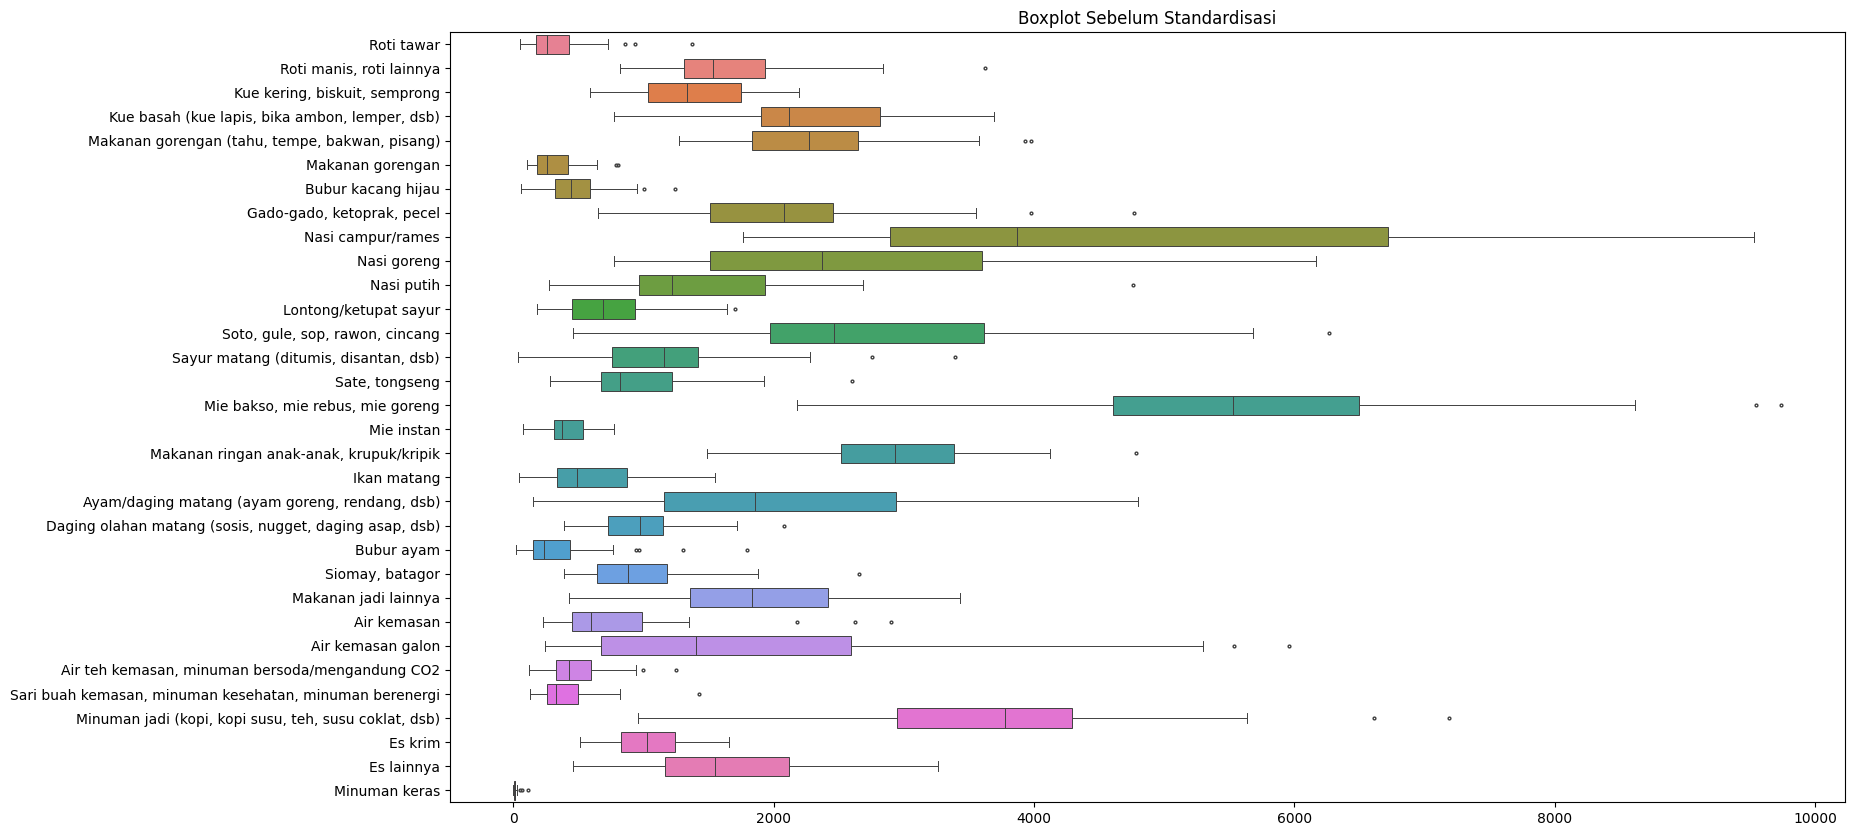

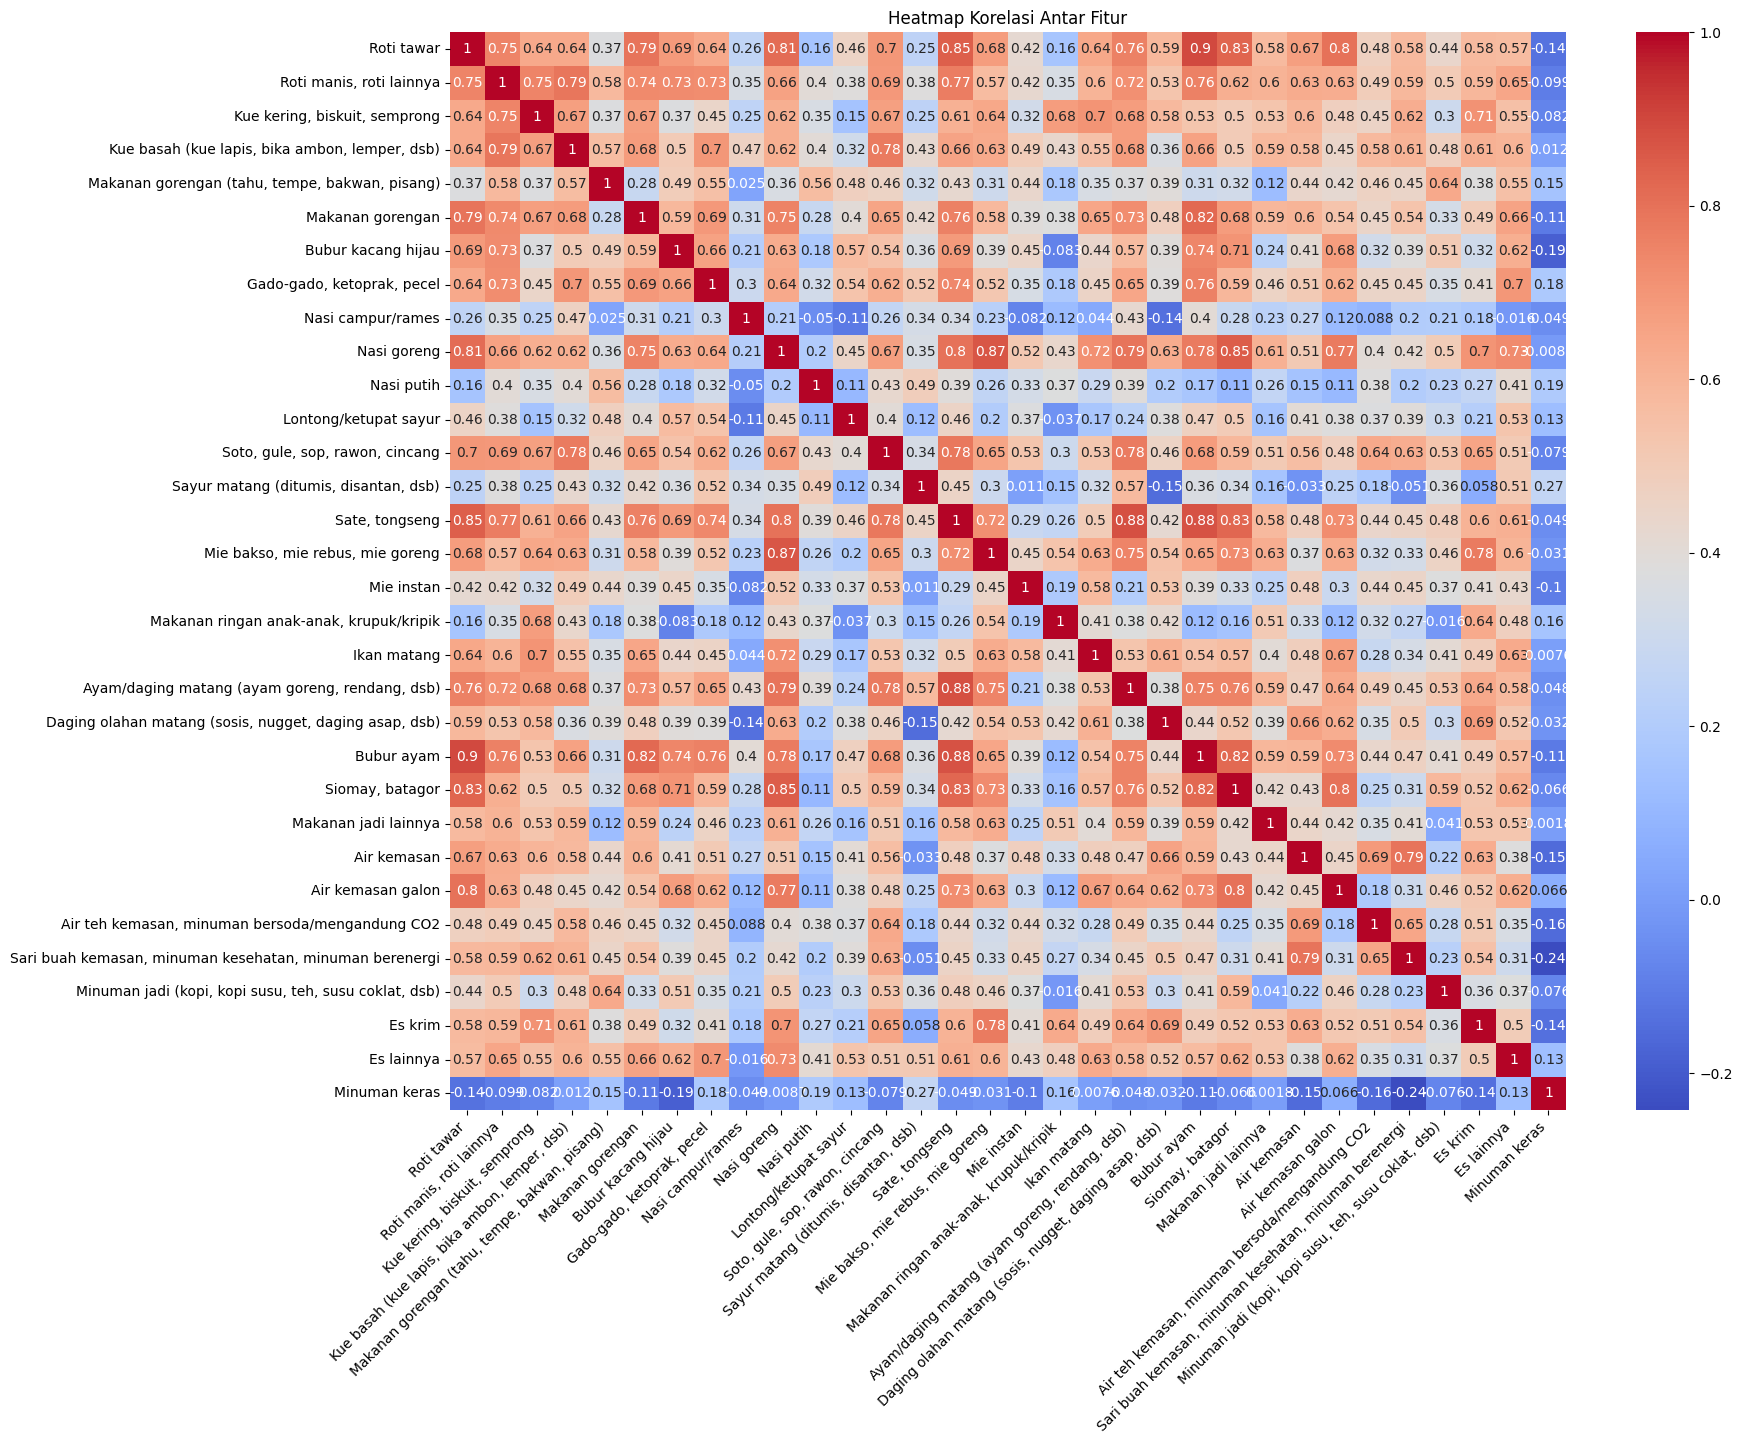

In [10]:

# 3. Visualisasi awal
plt.figure(figsize=(18, 10))
sns.boxplot(data=data_numerik, orient="h", linewidth=0.7, fliersize=2)
plt.title("Boxplot Sebelum Standardisasi")

plt.show()

plt.figure(figsize=(18, 14))
sns.heatmap(data_numerik.corr(), cmap='coolwarm', annot=True)
plt.title("Heatmap Korelasi Antar Fitur")
plt.xticks(rotation=45, ha='right') 
plt.show()

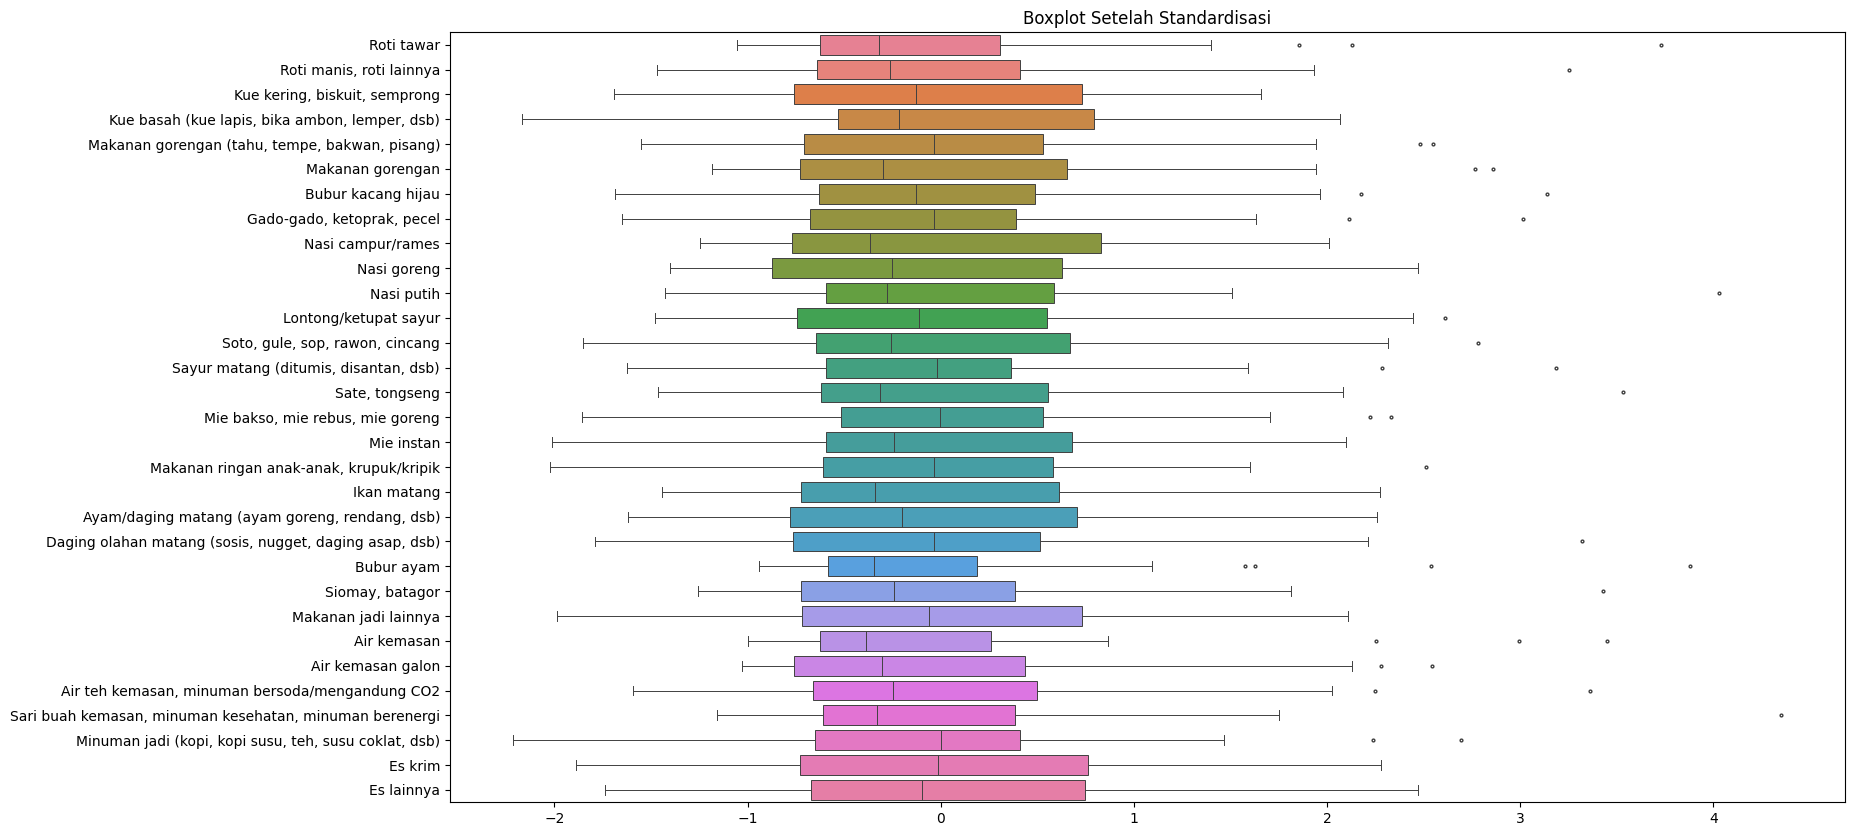

In [11]:
# 4. Hapus fitur outlier/minim informasi dan standardisasi
df = df.drop(columns=['Minuman keras'])
data_numerik = data_numerik.drop(columns=['Minuman keras'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(data_numerik), columns=data_numerik.columns, index=nama_daerah)

plt.figure(figsize=(18, 10))
sns.boxplot(data=df_scaled, orient="h", linewidth=0.7, fliersize=2)
plt.title("Boxplot Setelah Standardisasi")
plt.show()

Dendogram method single


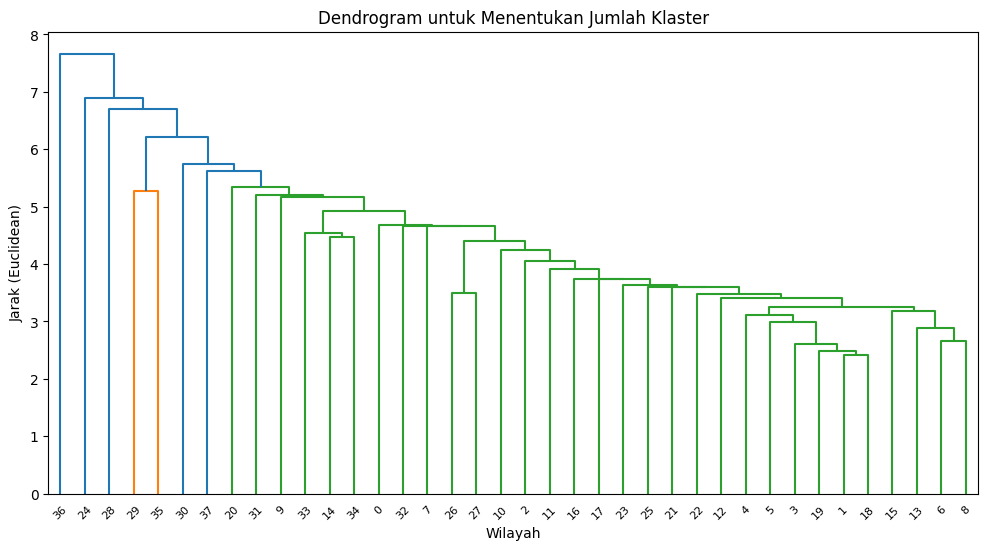

Dendogram method complete


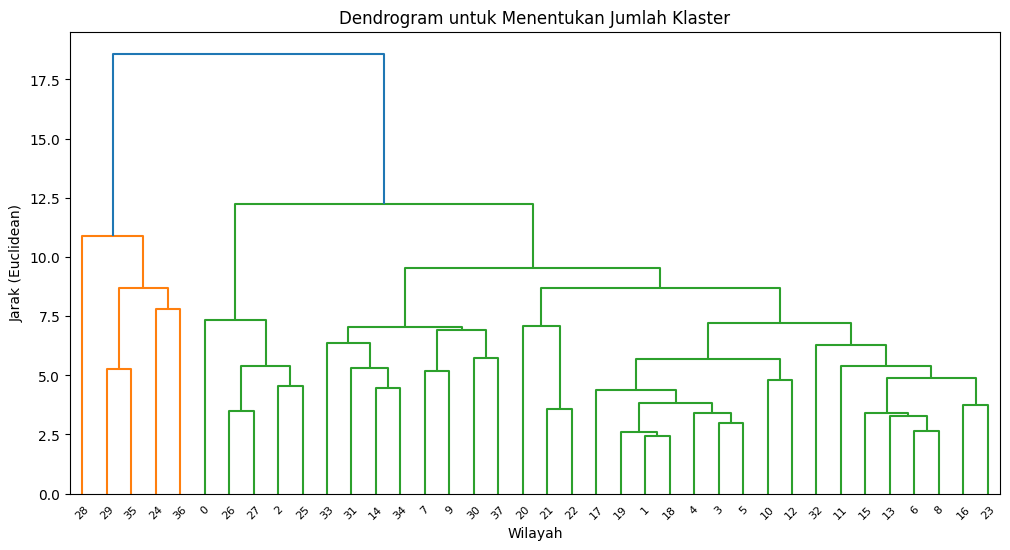

Dendogram method average


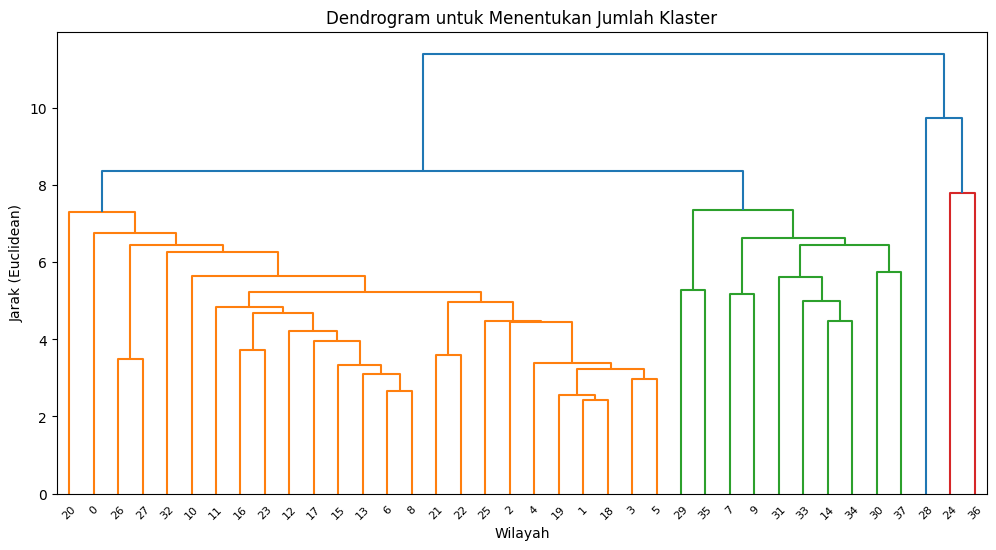

Dendogram method ward


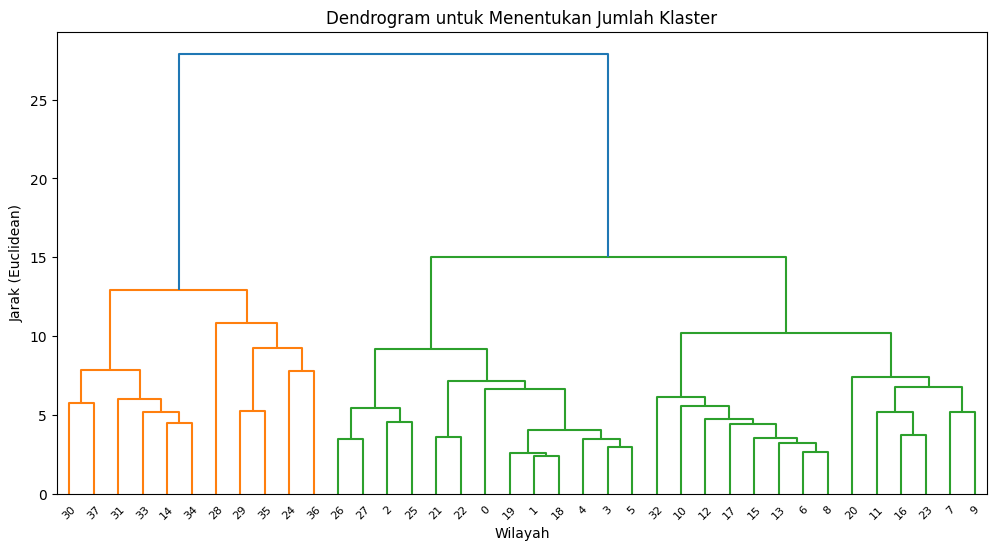

In [12]:
# 5. Dendrogram

method = ['single', 'complete', 'average', 'ward']

for i in method:
    print(f"Dendogram method {i}")
    plt.figure(figsize=(12, 6))
    dendrogram(linkage(df_scaled, method=i))
    plt.title("Dendrogram untuk Menentukan Jumlah Klaster")
    plt.xlabel("Wilayah")
    plt.ylabel("Jarak (Euclidean)")
    plt.show()

# print(f"Dendogram method {i}")
# plt.figure(figsize=(12, 6))
# dendrogram(linkage(df_scaled, method='ward'))
# plt.title("Dendrogram untuk Menentukan Jumlah Klaster")
# plt.xlabel("Wilayah")
# plt.ylabel("Jarak (Euclidean)")
# plt.show()




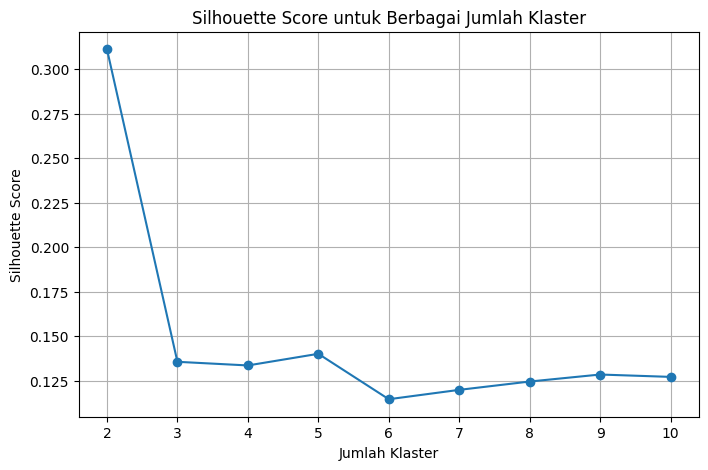

In [13]:
# 6. Silhouette Score untuk berbagai klaster
silhouette_scores = []
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = cluster.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Score untuk Berbagai Jumlah Klaster")
plt.xlabel("Jumlah Klaster")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()



Evaluating method: ward
Clusters: 2, Silhouette Score: 0.311
Clusters: 3, Silhouette Score: 0.136
Clusters: 4, Silhouette Score: 0.134
Clusters: 5, Silhouette Score: 0.140
Clusters: 6, Silhouette Score: 0.115
Clusters: 7, Silhouette Score: 0.120
Clusters: 8, Silhouette Score: 0.125
Clusters: 9, Silhouette Score: 0.128
Clusters: 10, Silhouette Score: 0.127

Evaluating method: complete
Clusters: 2, Silhouette Score: 0.362
Clusters: 3, Silhouette Score: 0.153
Clusters: 4, Silhouette Score: 0.142
Clusters: 5, Silhouette Score: 0.146
Clusters: 6, Silhouette Score: 0.147
Clusters: 7, Silhouette Score: 0.114
Clusters: 8, Silhouette Score: 0.112
Clusters: 9, Silhouette Score: 0.105
Clusters: 10, Silhouette Score: 0.093

Evaluating method: average
Clusters: 2, Silhouette Score: 0.366
Clusters: 3, Silhouette Score: 0.291
Clusters: 4, Silhouette Score: 0.258
Clusters: 5, Silhouette Score: 0.244
Clusters: 6, Silhouette Score: 0.223
Clusters: 7, Silhouette Score: 0.188
Clusters: 8, Silhouette Scor

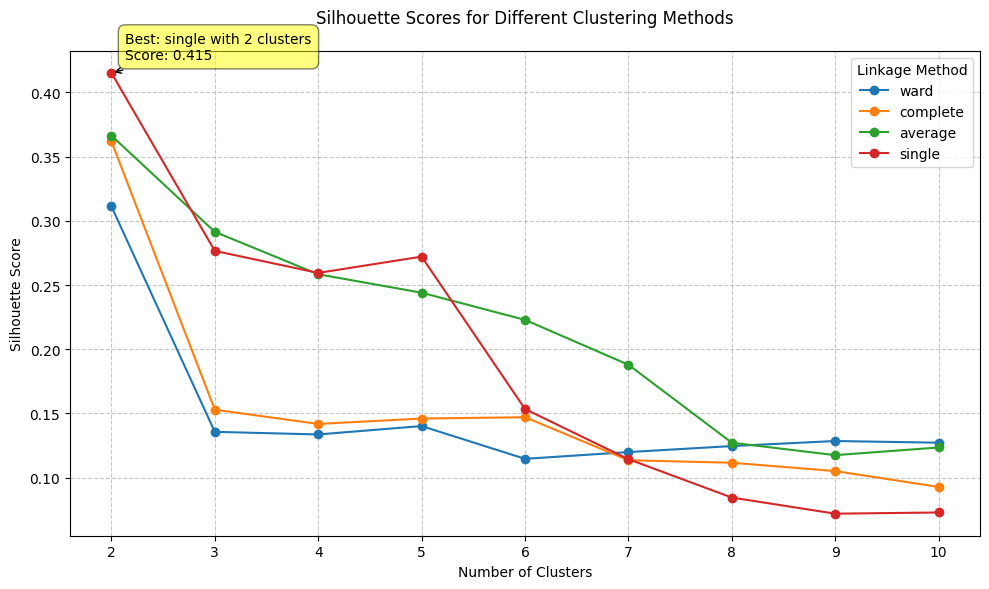


Best performing method: single with 2 clusters (score: 0.415)


In [14]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming df_scaled is your preprocessed data
silhouette_results = {}
methods = ['ward', 'complete', 'average', 'single']  # List of linkage methods to test
cluster_range = range(2, 11)  # Testing cluster numbers from 2 to 10

plt.figure(figsize=(10, 6))

for method in methods:
    method_scores = []
    print(f"\nEvaluating method: {method}")
    
    for n_clusters in cluster_range:
        # Create and fit the clustering model
        cluster = AgglomerativeClustering(n_clusters=n_clusters, 
                                        linkage=method, 
                                        metric='euclidean')  # Explicitly set metric
        
        labels = cluster.fit_predict(df_scaled)
        score = silhouette_score(df_scaled, labels)
        method_scores.append(score)
        
        print(f"Clusters: {n_clusters}, Silhouette Score: {score:.3f}")
    
    silhouette_results[method] = method_scores
    
    # Plot the results for this method
    plt.plot(cluster_range, method_scores, marker='o', label=method)

# Customize the plot
plt.title("Silhouette Scores for Different Clustering Methods", pad=20)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Linkage Method")
plt.tight_layout()

# Highlight the best score
best_method = max(silhouette_results, 
                 key=lambda x: max(silhouette_results[x]))
best_n = np.argmax(silhouette_results[best_method]) + 2  # +2 because range starts at 2
best_score = max(silhouette_results[best_method])

plt.annotate(f'Best: {best_method} with {best_n} clusters\nScore: {best_score:.3f}',
             xy=(best_n, best_score),
             xytext=(10, 10),
             textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
             arrowprops=dict(arrowstyle='->'))

plt.show()

# Return the best parameters
print(f"\nBest performing method: {best_method} with {best_n} clusters (score: {best_score:.3f})")

In [15]:
# 7. Model Hierarchical Clustering akhir
target_n = 3
model = AgglomerativeClustering(n_clusters=target_n, linkage='ward')
cluster_labels = model.fit_predict(df_scaled)

# Menambahkan hasil cluster ke DataFrame asli
df['Cluster'] = cluster_labels

C:\Users\USER\AppData\Local\Temp\ipykernel_14364\2883024285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=colors)


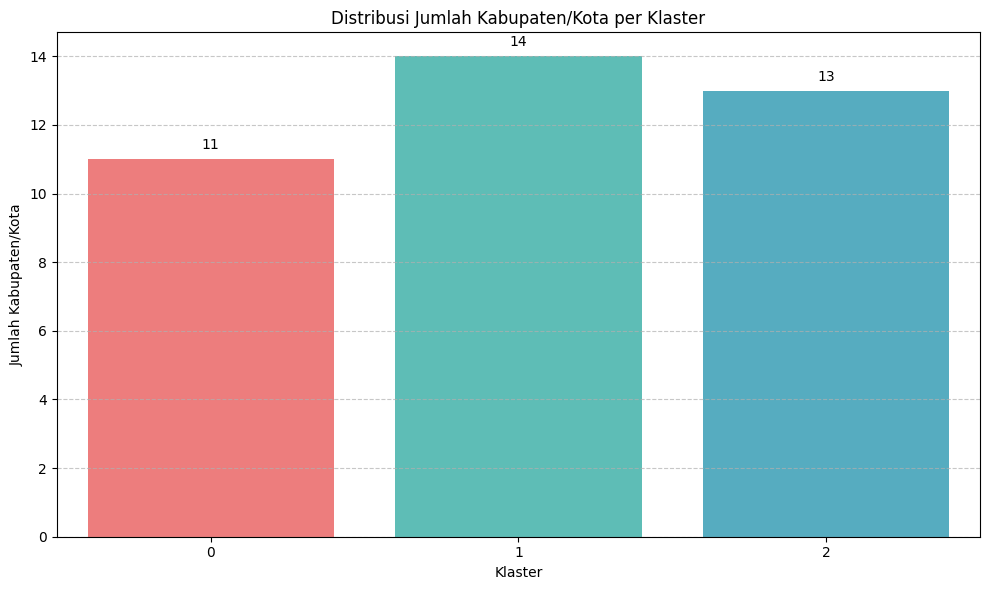

In [16]:
# 8. Distribusi Klaster
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cluster_counts = df['Cluster'].value_counts().sort_index()
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=colors)
plt.title('Distribusi Jumlah Kabupaten/Kota per Klaster')
plt.xlabel('Klaster')
plt.ylabel('Jumlah Kabupaten/Kota')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

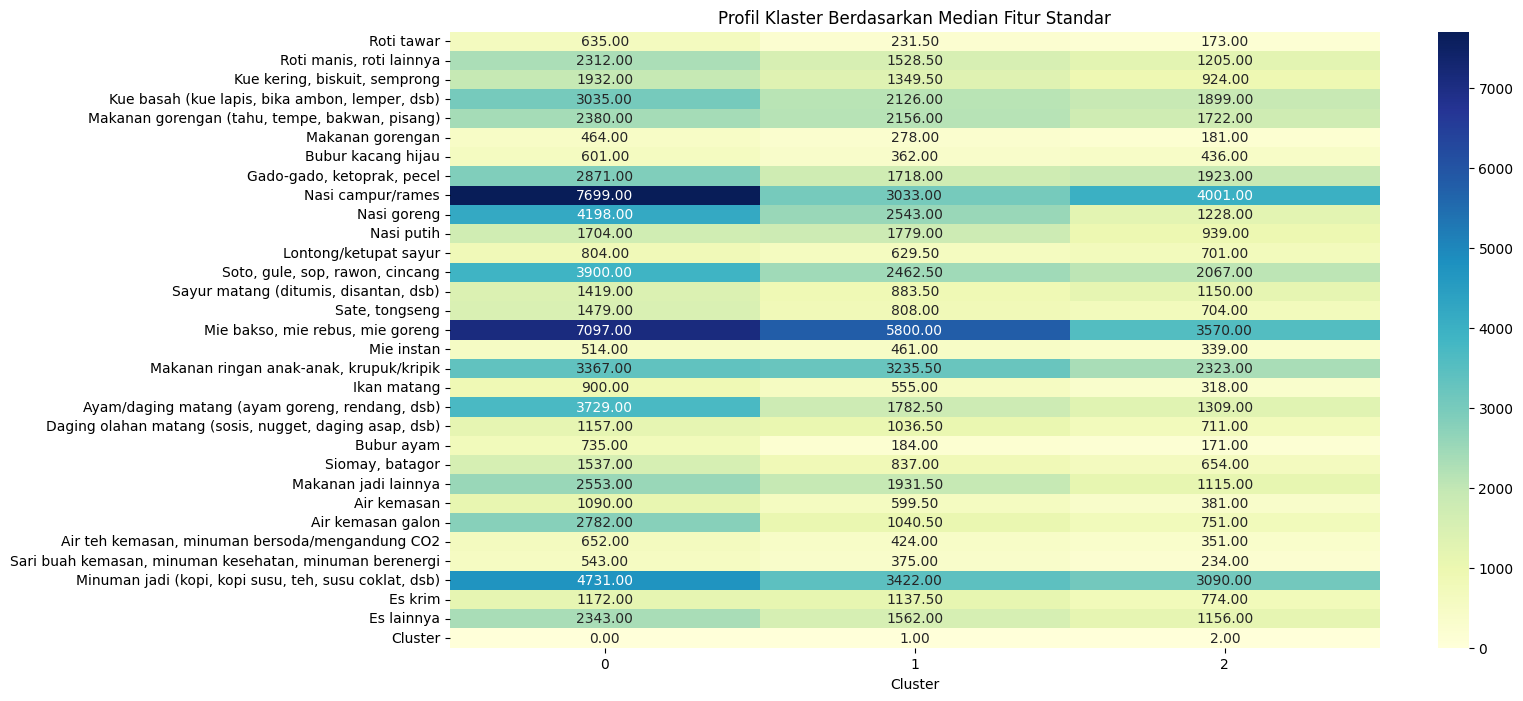

In [17]:
# 9. Profil Klaster
numeric_cols = df.select_dtypes(include=['number']).columns
cluster_profile = df.groupby('Cluster')[numeric_cols].median()

plt.figure(figsize=(15, 8))
sns.heatmap(cluster_profile.T, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("Profil Klaster Berdasarkan Median Fitur Standar")
plt.show()

In [18]:
# 10. Interpretasi Klaster
interpretation = {
    0: "Wilayah dengan pola pengeluaran tinggi",
    1: "Wilayah dengan pengeluaran menengah",
    2: "Wilayah dengan pengeluaran rendah"
}

C:\Users\USER\AppData\Local\Temp\ipykernel_14364\1572006219.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_14364\1572006219.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_14364\1572006219.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.values, y=data.index, palette='viridis')


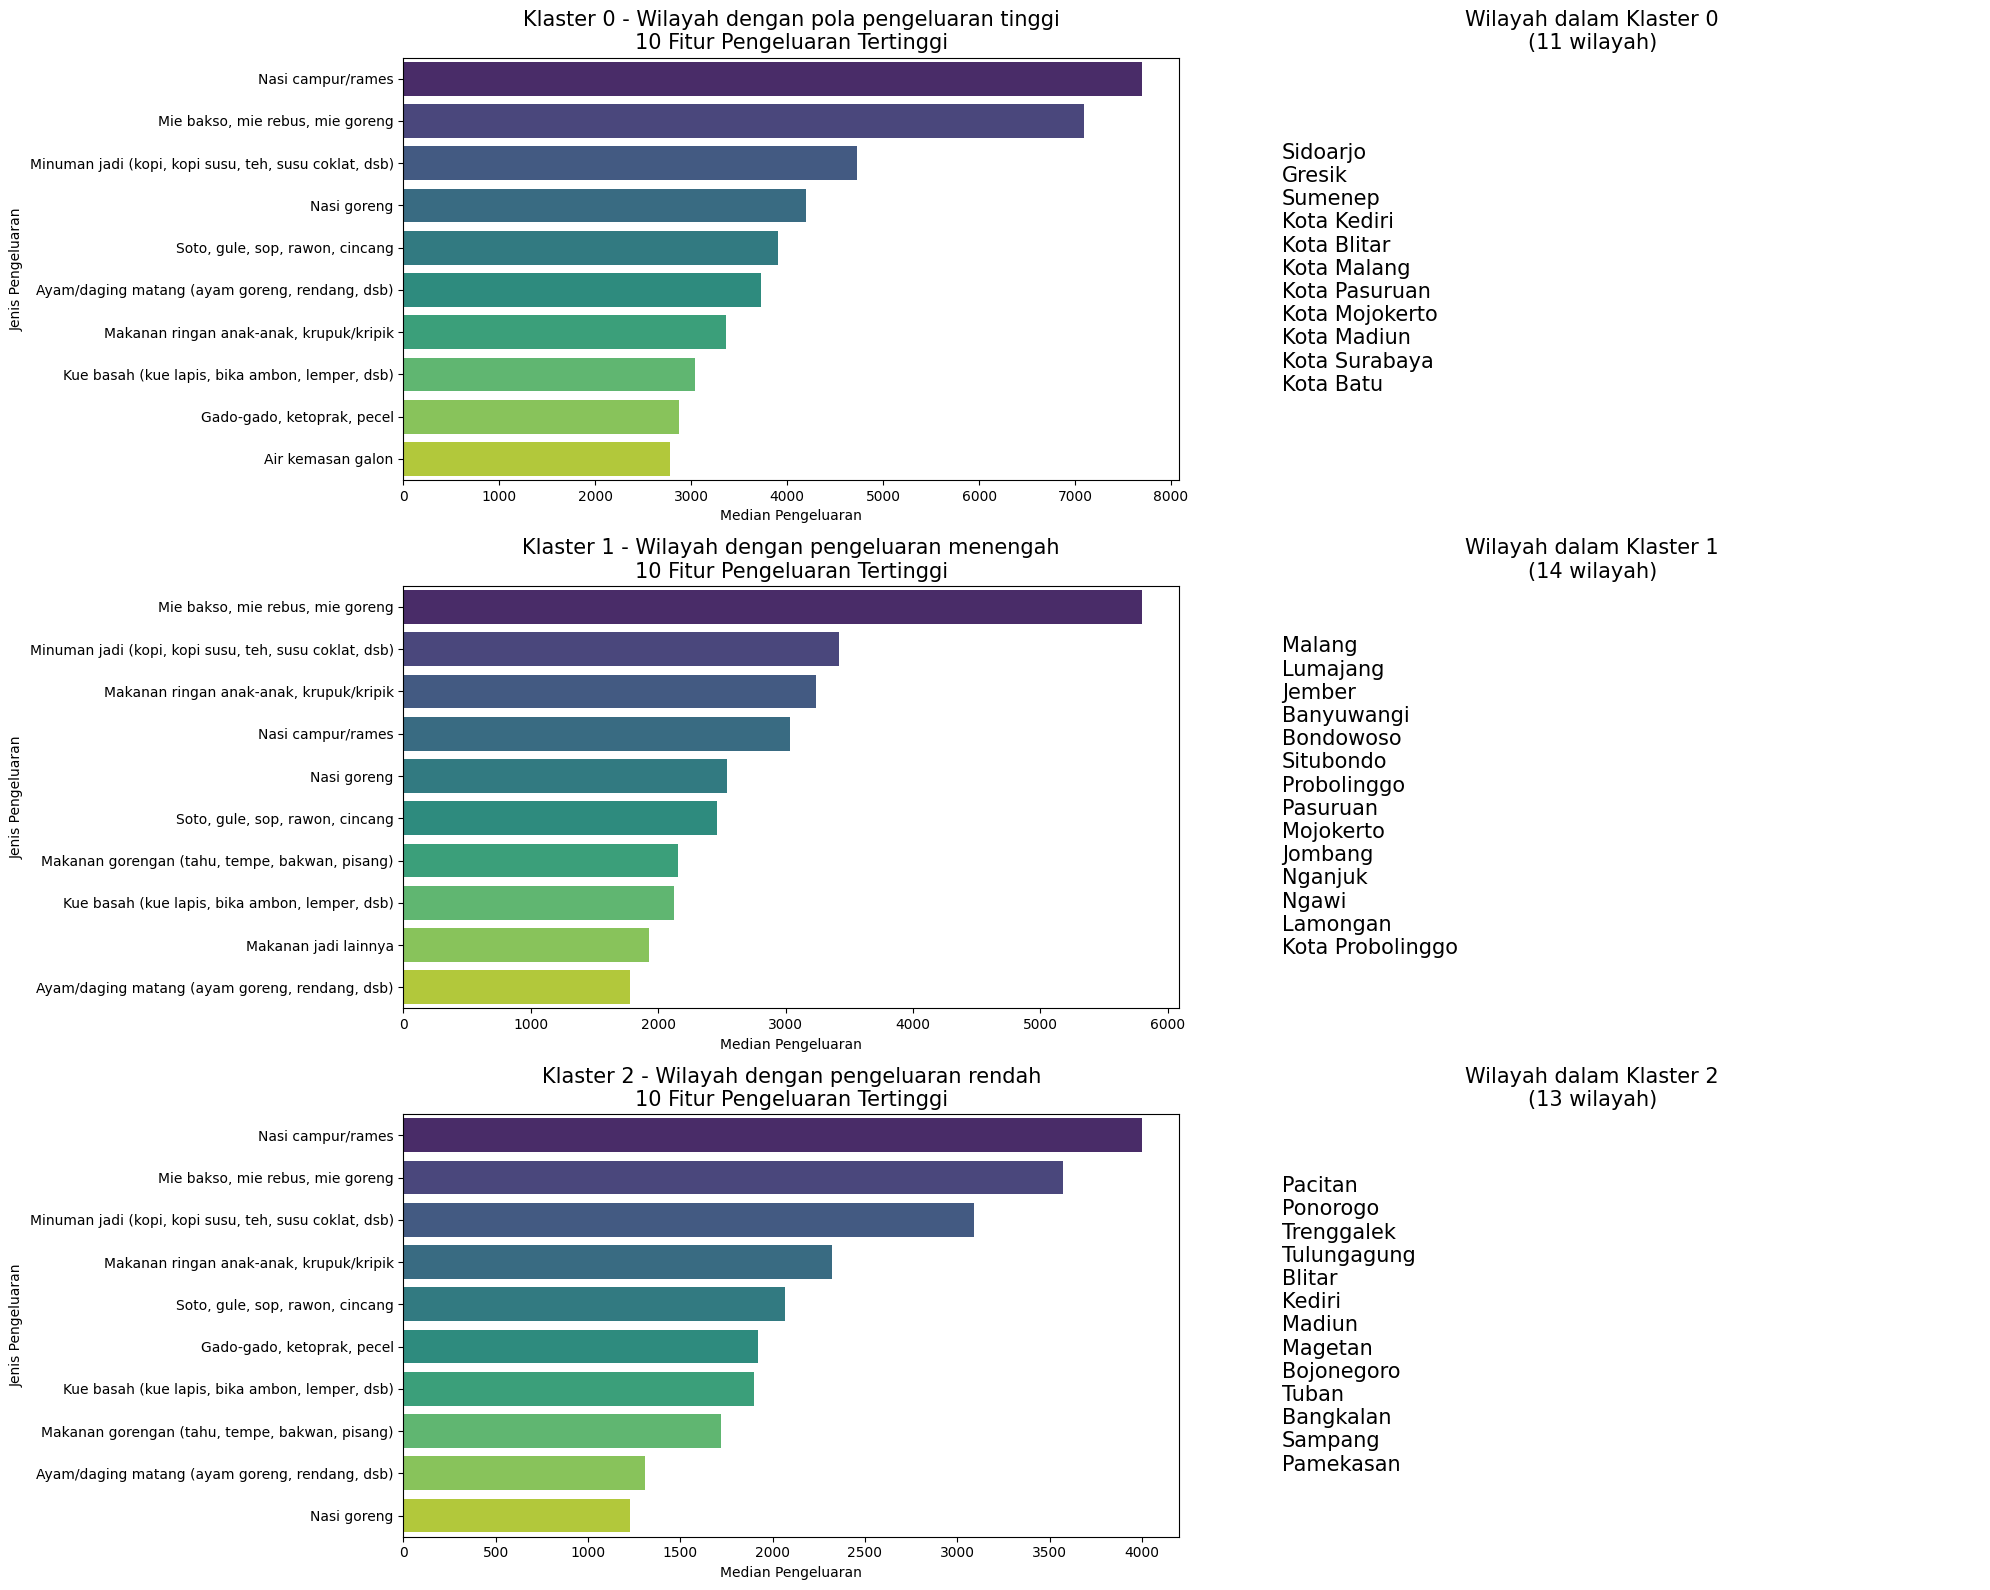

In [19]:
# Ambil 10 fitur tertinggi untuk setiap klaster
top_features_per_cluster = {}
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    median_values = cluster_data.drop(['Kabupaten/Kota', 'Cluster'], axis=1).median().sort_values(ascending=False)
    top_features_per_cluster[cluster] = median_values.head(10)

# Buat visualisasi
plt.figure(figsize=(20, 16))

for i, cluster in enumerate(top_features_per_cluster.keys()):
    # Plot grafik batang
    plt.subplot(3, 2, 2*i+1)
    data = top_features_per_cluster[cluster]
    sns.barplot(x=data.values, y=data.index, palette='viridis')
    plt.title(f'Klaster {cluster} - {interpretation[cluster]}\n10 Fitur Pengeluaran Tertinggi', fontsize=15)
    plt.xlabel('Median Pengeluaran', fontsize=10)
    plt.ylabel('Jenis Pengeluaran', fontsize=10)
    
    # Plot daftar wilayah
    plt.subplot(3, 2, 2*i+2)
    wilayah = df[df['Cluster'] == cluster]['Kabupaten/Kota'].values
    plt.text(0.1, 0.5, "\n".join(wilayah), 
             ha='left', va='center', fontsize=15)
    plt.title(f'Wilayah dalam Klaster {cluster}\n({len(wilayah)} wilayah)', fontsize=15)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
cluster_profile

,Roti tawar,"Roti manis, roti lainnya","Kue kering, biskuit, semprong","Kue basah (kue lapis, bika ambon, lemper, dsb)","Makanan gorengan (tahu, tempe, bakwan, pisang)",Makanan gorengan,Bubur kacang hijau,"Gado-gado, ketoprak, pecel",Nasi campur/rames,Nasi goreng,...,"Siomay, batagor",Makanan jadi lainnya,Air kemasan,Air kemasan galon,"Air teh kemasan, minuman bersoda/mengandung CO2","Sari buah kemasan, minuman kesehatan, minuman berenergi","Minuman jadi (kopi, kopi susu, teh, susu coklat, dsb)",Es krim,Es lainnya,Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,635.0,2312.0,1932.0,3035.0,2380.0,464.0,601.0,2871.0,7699.0,4198.0,...,1537.0,2553.0,1090.0,2782.0,652.0,543.0,4731.0,1172.0,2343.0,0.0
1,231.5,1528.5,1349.5,2126.0,2156.0,278.0,362.0,1718.0,3033.0,2543.0,...,837.0,1931.5,599.5,1040.5,424.0,375.0,3422.0,1137.5,1562.0,1.0
2,173.0,1205.0,924.0,1899.0,1722.0,181.0,436.0,1923.0,4001.0,1228.0,...,654.0,1115.0,381.0,751.0,351.0,234.0,3090.0,774.0,1156.0,2.0


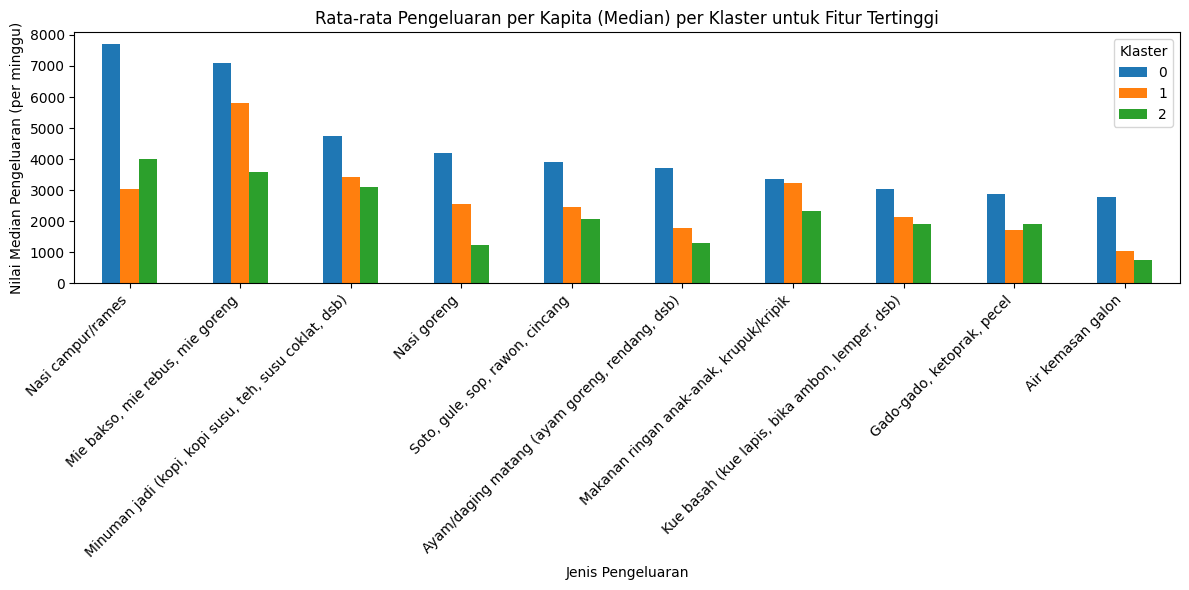

In [21]:
# Visualisasi Barchart per Klaster untuk Beberapa Fitur Terpilih
# fitur berdasarkan nilai median tertinggi di semua klaster

# Ambil fitur dengan median tertinggi di seluruh klaster
top_features = cluster_profile.max().sort_values(ascending=False).head(10).index

# Plot barchart untuk setiap fitur tersebut per klaster
cluster_profile[top_features].T.plot(kind='bar', figsize=(12, 6))
plt.title("Rata-rata Pengeluaran per Kapita (Median) per Klaster untuk Fitur Tertinggi")
plt.xlabel("Jenis Pengeluaran")
plt.ylabel("Nilai Median Pengeluaran (per minggu)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Klaster")
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_14364\3613812769.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=feature, data=df, palette= "Set2")
C:\Users\USER\AppData\Local\Temp\ipykernel_14364\3613812769.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=feature, data=df, palette= "Set2")
C:\Users\USER\AppData\Local\Temp\ipykernel_14364\3613812769.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y=feature, data=df, palette= "Set2")
C:\Users\USER\AppData\Local\Temp\ipykernel_14364\361381276

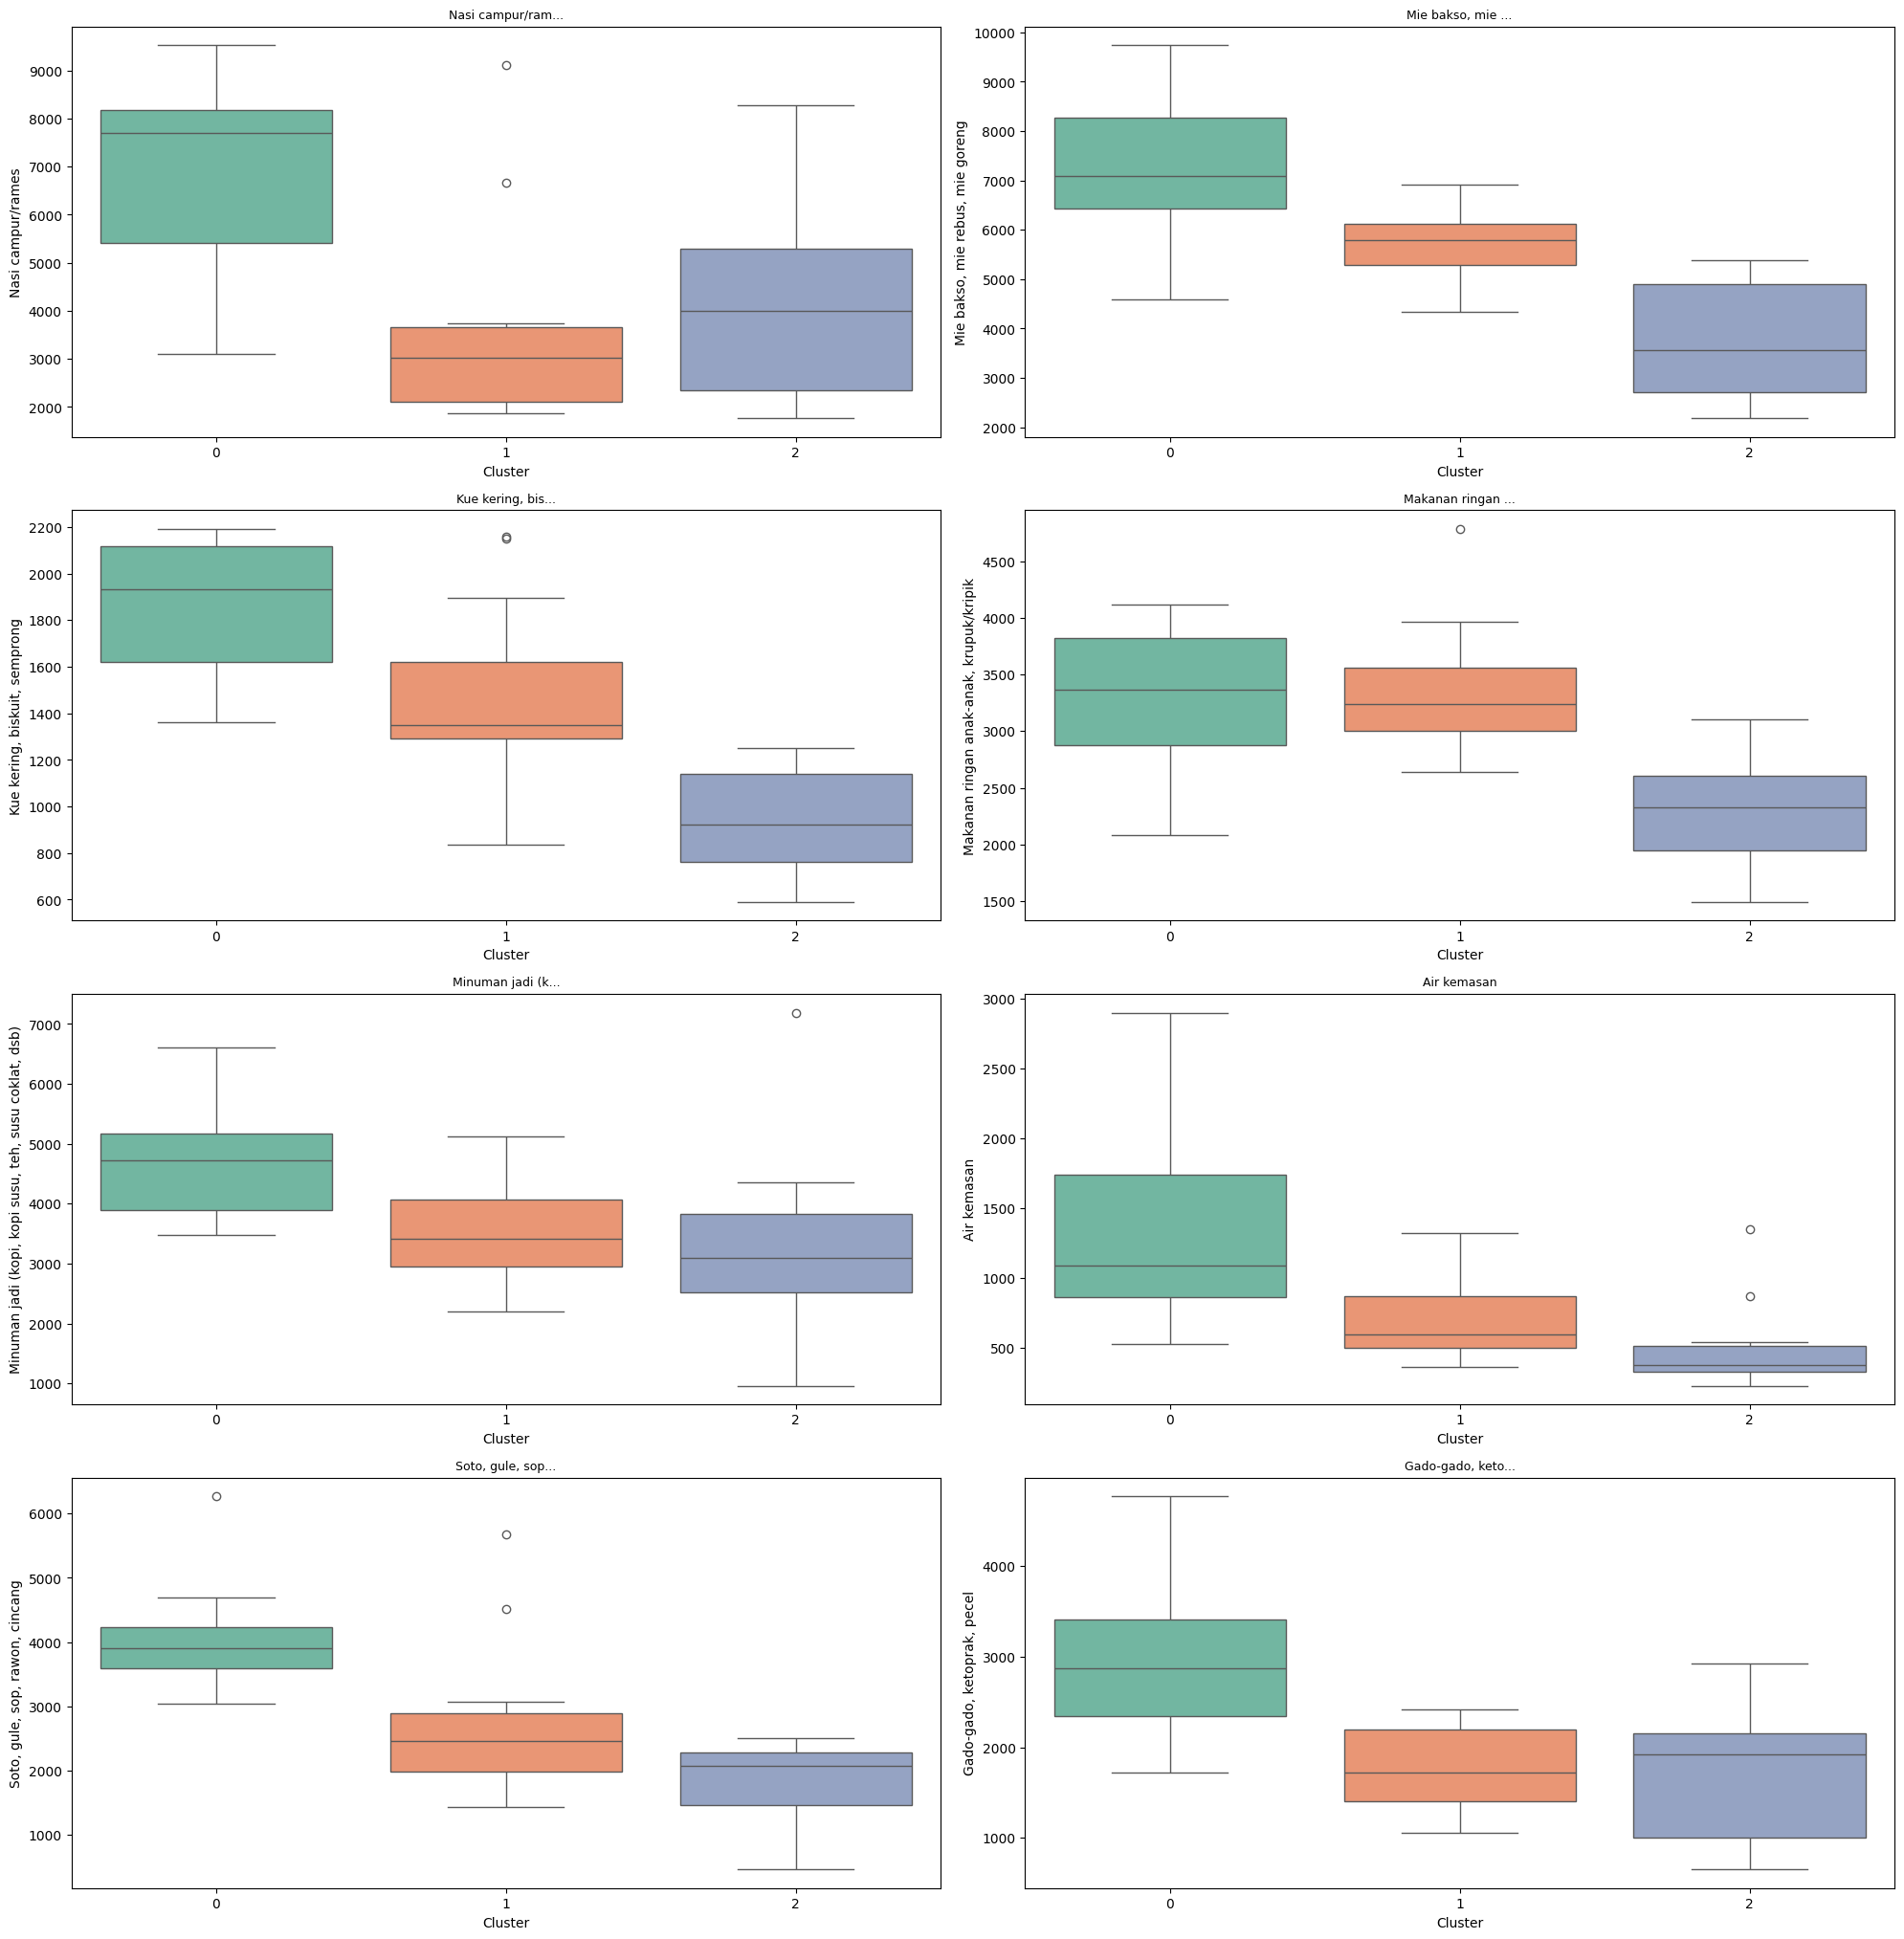

In [22]:
# Fitur yang dipilih untuk visualisasi boxplot
selected_features = [
    "Nasi campur/rames",
    "Mie bakso, mie rebus, mie goreng",
    "Kue kering, biskuit, semprong",
    "Makanan ringan anak-anak, krupuk/kripik",
    "Minuman jadi (kopi, kopi susu, teh, susu coklat, dsb)",
    "Air kemasan",
    "Soto, gule, sop, rawon, cincang",
    "Gado-gado, ketoprak, pecel"
]


plt.figure(figsize=(20, 25))  # Perbesar ukuran figure
for i, feature in enumerate(selected_features, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x="Cluster", y=feature, data=df, palette= "Set2")
    plt.title(f'{feature[:15]}...' if len(feature) > 15 else feature, fontsize=9)
plt.tight_layout()


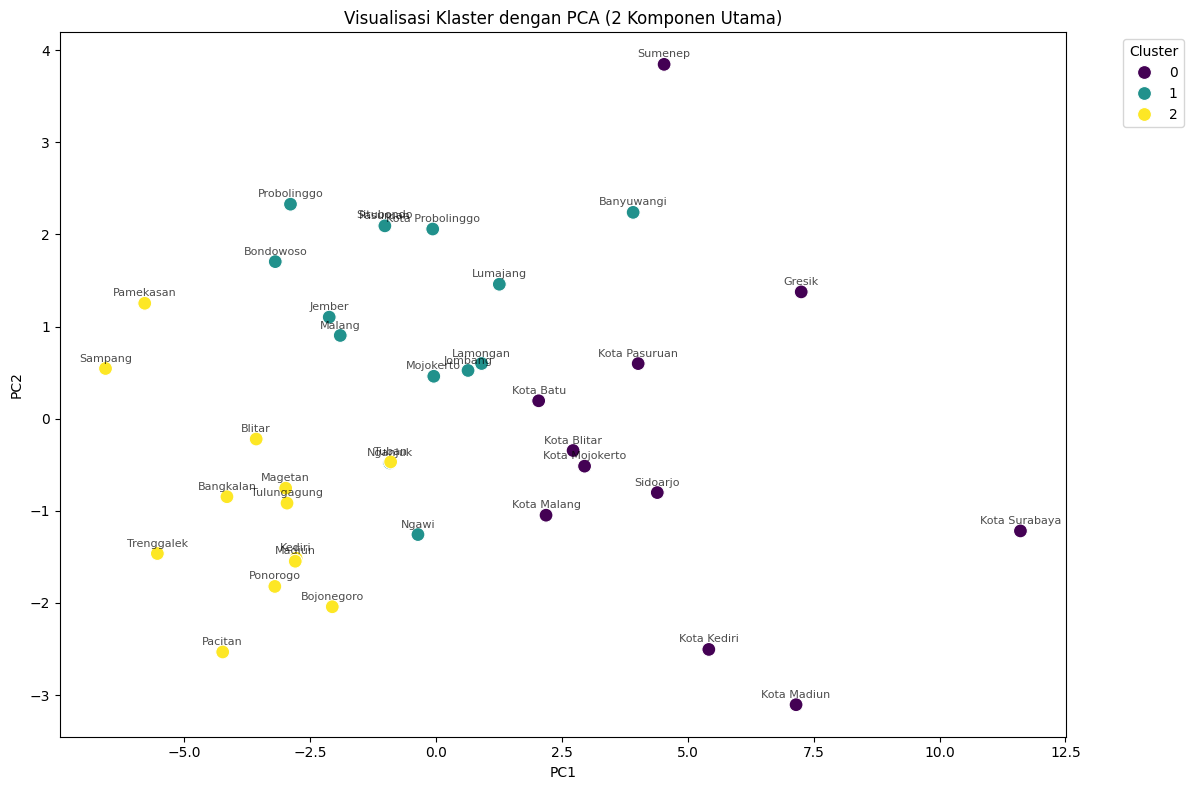

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reduksi dimensi dengan PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels
df_pca['Kabupaten/Kota'] = nama_daerah.values

plt.figure(figsize=(12, 8))

# Plot scatter dengan warna berbeda per cluster
scatter = sns.scatterplot(x='PC1', y='PC2', hue='Cluster', 
                         data=df_pca, palette='viridis', s=100)
plt.title('Visualisasi Klaster dengan PCA (2 Komponen Utama)')

# Tambahkan label untuk setiap titik
for line in range(0, df_pca.shape[0]):
    plt.annotate(df_pca['Kabupaten/Kota'].iloc[line], 
                (df_pca['PC1'].iloc[line], df_pca['PC2'].iloc[line]),
                textcoords="offset points",
                xytext=(0,5),
                ha='center',
                fontsize=8,
                alpha=0.7)

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
# Simpan hasil klaster ke file Excel
# df.to_excel("Hasil_Klaster_Pengeluaran_Jatim.xlsx", index=False)
# print("\nHasil klaster telah disimpan ke file Excel.")